<>:62: SyntaxWarning: invalid escape sequence '\i'
<>:62: SyntaxWarning: invalid escape sequence '\i'
C:\Users\amarg\AppData\Local\Temp\ipykernel_26000\1751932561.py:62: SyntaxWarning: invalid escape sequence '\i'
  ax.plot(omega_R_real, omega_R_imag, 'g--', linewidth=2, label="Semicircular Path $C_R$ ($R \to \infty$)")


--- 1. SYMBOLIC RESIDUE CALCULATION (SymPy) ---
Given rational frequency-domain function X(j\omega):


1/(alpha + I*omega)

Identified pole in the complex plane:


I*alpha


Computed Residue at omega = j*alpha:


-I*exp(-alpha*t)


Derived inverse Fourier transform x(t) for t > 0:


exp(-alpha*t)

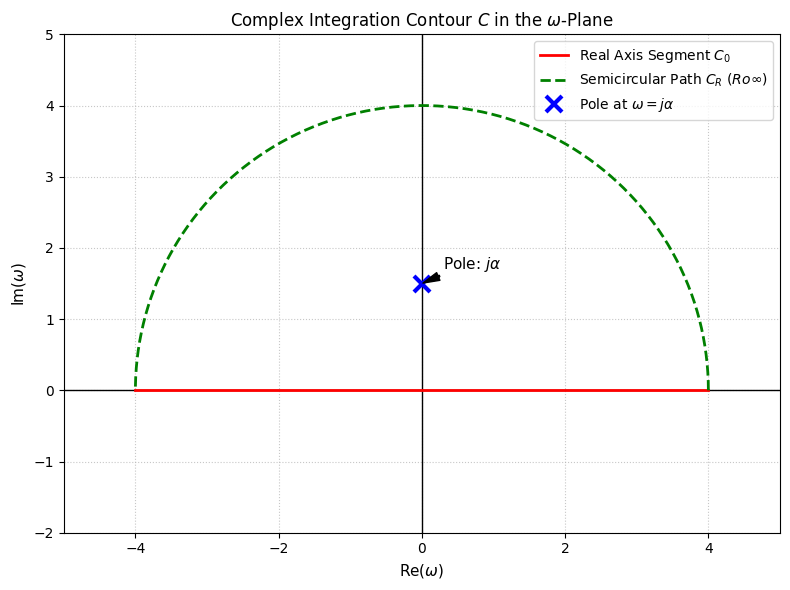

In [1]:
# Notebook: Inverse Fourier Transform via Complex Integration and Residue Theorem
# Function to invert: X(j\omega) = 1 / (\alpha + j\omega)

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define complex and real symbols
t, omega = sp.symbols('t omega', real=True)
alpha = sp.symbols('alpha', positive=True, real=True)

# 1. Define the rational frequency-domain function X(j\omega) = 1 / (\alpha + j\omega)
# Note: j in SymPy is represented by sp.I
X_omega = 1 / (alpha + sp.I * omega)

print("--- 1. SYMBOLIC RESIDUE CALCULATION (SymPy) ---")
print("Given rational frequency-domain function X(j\\omega):")
display(X_omega)

# Find the pole by setting the denominator to zero: \alpha + j\omega = 0 => \omega = j\alpha
pole = -alpha / sp.I  # which is j*alpha
print(f"Identified pole in the complex plane:")
display(pole)

# The integrand for the inverse Fourier transform: X(j\omega) * e^{j\omega t}
integrand = X_omega * sp.exp(sp.I * omega * t)

# Compute the residue at the pole \omega = j\alpha using SymPy's residue function
# resid(f(omega), omega, pole)
residue_val = sp.residue(integrand, omega, pole)

print("\nComputed Residue at omega = j*alpha:")
display(residue_val)

# By Cauchy's Residue Theorem: \oint_C integrand d\omega = 2\pi j * Residue
contour_integral = 2 * sp.pi * sp.I * residue_val
x_t_result = sp.simplify((1 / (2 * sp.pi)) * contour_integral)

print("\nDerived inverse Fourier transform x(t) for t > 0:")
display(x_t_result)


# ==========================================================
# 2. VISUALIZATION OF THE COMPLEX PLANE AND THE CONTOUR
# ==========================================================
def plot_complex_contour():
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Draw the complex plane axes (Real axis vs Imaginary axis)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    
    # Draw the integration contour C (Upper semicircle of radius R + real axis segment)
    R = 4.0
    # Real axis segment from -R to R
    ax.plot([-R, R], [0, 0], 'r-', linewidth=2, label="Real Axis Segment $C_0$")
    
    # Upper semicircle path
    theta = np.linspace(0, np.pi, 200)
    omega_R_real = R * np.cos(theta)
    omega_R_imag = R * np.sin(theta)
    ax.plot(omega_R_real, omega_R_imag, 'g--', linewidth=2, label="Semicircular Path $C_R$ ($R \to \infty$)")
    
    # Plot the pole at \omega = j*alpha (let's assume alpha = 1.5 for visualization)
    alpha_val = 1.5
    ax.plot(0, alpha_val, 'bx', markersize=12, markeredgewidth=3, label=r"Pole at $\omega = j\alpha$")
    
    ax.set_title(r"Complex Integration Contour $C$ in the $\omega$-Plane", fontsize=12)
    ax.set_xlabel(r"Re($\omega$)", fontsize=11)
    ax.set_ylabel(r"Im($\omega$)", fontsize=11)
    ax.grid(True, linestyle=":", alpha=0.7)
    
    # Annotations
    ax.annotate(r"Pole: $j\alpha$", xy=(0, alpha_val), xytext=(0.3, alpha_val + 0.2),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6), fontsize=11)
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-2, 5)
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Execute the complex plane visualization
plot_complex_contour()